# 1. Сеть, проверка против диплома и анализ чувствительности

Ноутбук собирает байесовскую сеть, проверяет её на трёх диагностических
сценариях Табл. 3.6 и систематически исследует, как выходы реагируют на
входы.

Структура — §3.2 ВКР с восстановленными по опросу эксперта дугами: в
текстовом описании работы часть связей отсутствовала, из-за чего узел
температуры оказывался мёртвым. Итог — 20 дуг вместо исходных 13; разбор
в README, раздел 4.3.

Все числа берутся из `src/network_spec.py` — единственного источника истины
по структуре и CPT. Что в них взято из диплома точно, что реконструировано,
а что подогнано под Табл. 3.6, разобрано в README, раздел 4.2. Различие
существенное: `CPT_FAILURE` подогнана, и это меняет статус проверки в
разделе 1.3.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.model import BayesNet
from src.network_spec import STATES, EDGES, RUSSIAN_NAME, SCENARIOS_TABLE_3_6, TARGET_HIGH_STATE

pd.set_option("display.width", 150)
net = BayesNet.from_spec()
print(f"Узлов: {len(net.states)}   дуг: {len(EDGES)}   свободных параметров: {net.n_free_params}")
print("Топологический порядок:", " → ".join(net.order))

Узлов: 11   дуг: 20   свободных параметров: 428
Топологический порядок: pressure → temperature → flow → calibration → age → device_cond → pipe_cond → reliability → failure_prob → anomaly → maintenance


## 1.1 Три уровня сети

Вход (то, что реально приходит с АИС) → скрытые состояния → управленческие
гипотезы. Скрытый слой здесь принципиален: без него пришлось бы связывать
показания приборов с решениями напрямую, то есть теми самыми пороговыми
правилами, которые диплом критикует в §3.1.

In [2]:
levels = {
    "вход (АИС)": ["pressure", "temperature", "flow", "calibration", "age"],
    "скрытые состояния": ["device_cond", "pipe_cond", "reliability"],
    "выход (решения)": ["failure_prob", "maintenance", "anomaly"],
}
rows = []
for level, nodes in levels.items():
    for v in nodes:
        parents = net.parents.get(v, ())
        rows.append({"уровень": level, "узел": v, "название": RUSSIAN_NAME[v],
                     "состояний": len(STATES[v]),
                     "родители": ", ".join(parents) if parents else "—"})
display_df = pd.DataFrame(rows)
print(display_df.to_string(index=False))

          уровень         узел                         название  состояний                                          родители
       вход (АИС)     pressure          Давление в трубопроводе          2                                                 —
       вход (АИС)  temperature        Температура теплоносителя          2                                                 —
       вход (АИС)         flow       Расход (объём потребления)          3                                                 —
       вход (АИС)  calibration         Срок с последней поверки          3                                                 —
       вход (АИС)          age        Срок эксплуатации прибора          3                                                 —
скрытые состояния  device_cond    Техническое состояние прибора          3           pressure, temperature, calibration, age
скрытые состояния    pipe_cond Состояние трубопровода (системы)          3                       pressure, temperature, flow


## 1.2 Априорные распределения выходов

«Что модель думает до того, как увидела хоть один прибор». Это опорная
точка: любые апостериорные числа ниже осмысленно читать только в сравнении
с ней.

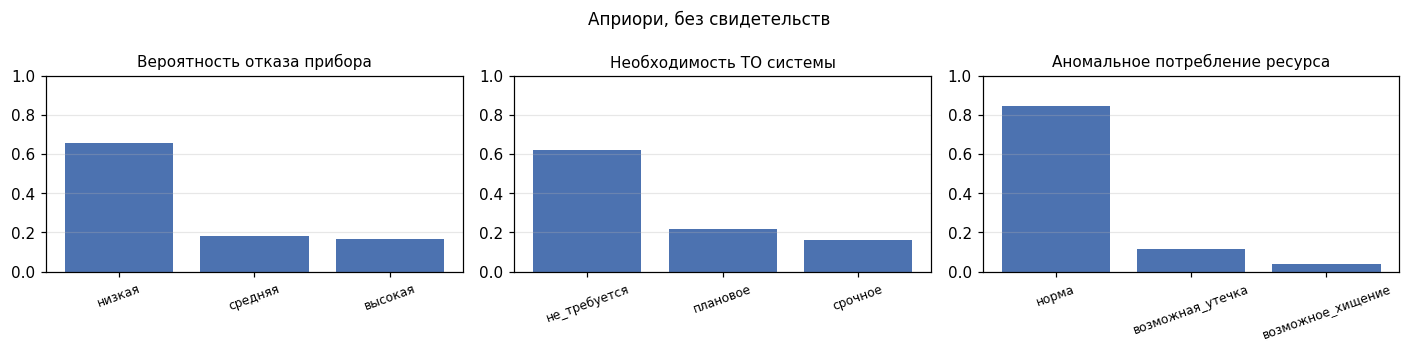

In [3]:
targets = ["failure_prob", "maintenance", "anomaly"]
prior = net.posterior({}, targets)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, t in zip(axes, targets):
    ax.bar(STATES[t], prior[t], color="#4c72b0")
    ax.set_title(RUSSIAN_NAME[t], fontsize=10)
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=.3)
fig.suptitle("Априори, без свидетельств", fontsize=11)
fig.tight_layout()
plt.show()

## 1.3 Проверка против Таблицы 3.6

Три сценария из диплома — единственная опубликованная точка сверки с
оригинальной моделью в HUGIN. Полные CPT в текст работы не выгружены,
поэтому большая часть таблиц реконструирована.

**Как читать эту таблицу.** Совпадение по `maintenance` и `anomaly` —
содержательная проверка: их CPT собраны из качественной логики §3.2 и под
эти числа не подбирались. Совпадение по `failure_prob` — не проверка:
таблица подогнана ровно под эти шесть чисел (гипотеза B, ноутбук 3), так
что здесь сверка работает как регрессионный тест на случайную порчу
данных, и не более того. Разделять эти два случая обязательно, иначе
общая цифра согласия вводит в заблуждение.

In [4]:
rows = []
for name, spec in SCENARIOS_TABLE_3_6.items():
    post = net.posterior(spec["evidence"], targets)
    for t, thesis_p in spec["thesis_posterior"].items():
        hi = TARGET_HIGH_STATE[t]
        model_p = float(post[t][STATES[t].index(hi)])
        rows.append({"сценарий": name.split("(")[0].strip(), "узел": t,
                     "состояние": hi, "модель": round(model_p, 3),
                     "диплом": thesis_p, "Δ": round(model_p - thesis_p, 3),
                     "статус": "OK" if abs(model_p - thesis_p) <= 0.10 else "расхождение"})
check = pd.DataFrame(rows)
print(check.to_string(index=False))

  сценарий         узел        состояние  модель  диплом      Δ статус
Сценарий 1 failure_prob          высокая   0.442    0.42  0.022     OK
Сценарий 1  maintenance          срочное   0.548    0.58 -0.032     OK
Сценарий 1      anomaly возможная_утечка   0.596    0.67 -0.074     OK
Сценарий 2 failure_prob          высокая   0.514    0.52 -0.006     OK
Сценарий 2  maintenance          срочное   0.412    0.40  0.012     OK
Сценарий 2      anomaly возможная_утечка   0.128    0.09  0.038     OK
Сценарий 3 failure_prob          высокая   0.642    0.70 -0.058     OK
Сценарий 3  maintenance          срочное   0.425    0.35  0.075     OK
Сценарий 3      anomaly возможная_утечка   0.224    0.18  0.044     OK


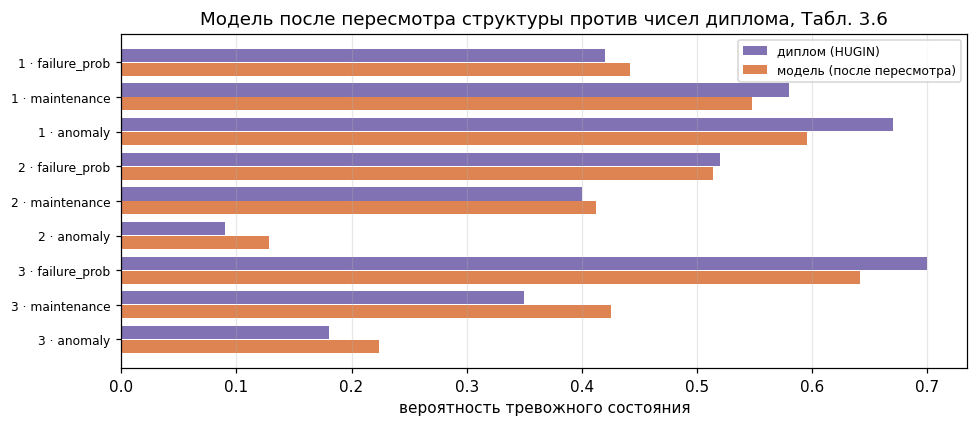

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(check))
ax.barh(y - 0.2, check["диплом"], height=0.38, label="диплом (HUGIN)", color="#8172b3")
ax.barh(y + 0.2, check["модель"], height=0.38, label="модель (после пересмотра)", color="#dd8452")
ax.set_yticks(y, [f"{r.сценарий[-1]} · {r.узел}" for r in check.itertuples()], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("вероятность тревожного состояния")
ax.set_title("Модель после пересмотра структуры против чисел диплома, Табл. 3.6")
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=.3)
fig.tight_layout()
plt.show()

## 1.4 Explaining away — то, ради чего берут байесовскую сеть

Аномально высокий расход сам по себе выглядит как утечка. Но если прибор
старый и поверка просрочена, у показаний появляется конкурирующее
объяснение: «прибор врёт». Вероятностный вывод должен сам перераспределить
массу в пользу второй гипотезы — без единого явно прописанного правила.

In [6]:
base = dict(pressure="norma", temperature="norma", flow="anomal_high")
cases = {
    "новый прибор, поверка в норме": dict(base, calibration="v_norme", age="lt_3"),
    "средний возраст, поверка подходит": dict(base, calibration="priblizhaetsya", age="3_7"),
    "старый прибор, поверка истекла": dict(base, calibration="istek", age="gt_7"),
}
rows = []
for label, ev in cases.items():
    post = net.posterior(ev, ["anomaly", "reliability"])
    rows.append({
        "состояние прибора": label,
        "P(возможная утечка)": round(float(post["anomaly"][STATES["anomaly"].index("возможная_утечка")]), 3),
        "P(показания недостоверны)": round(float(post["reliability"][STATES["reliability"].index("недостоверная")]), 3),
    })
ea = pd.DataFrame(rows)
print(ea.to_string(index=False))
print("\nРасход во всех трёх случаях одинаково аномальный. Тревога по утечке")
print(f"падает с {ea.iloc[0, 1]:.2f} до {ea.iloc[-1, 1]:.2f} ровно потому, что растёт")
print("вероятность альтернативного объяснения — неисправности самого прибора.")

                состояние прибора  P(возможная утечка)  P(показания недостоверны)
    новый прибор, поверка в норме                0.256                      0.390
средний возраст, поверка подходит                0.245                      0.445
   старый прибор, поверка истекла                0.224                      0.548

Расход во всех трёх случаях одинаково аномальный. Тревога по утечке
падает с 0.26 до 0.22 ровно потому, что растёт
вероятность альтернативного объяснения — неисправности самого прибора.


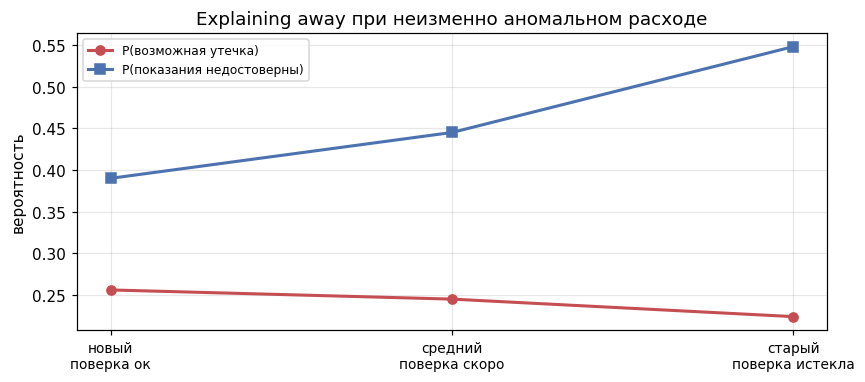

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(ea))
ax.plot(x, ea["P(возможная утечка)"], "-o", lw=2, label="P(возможная утечка)", color="#c44e52")
ax.plot(x, ea["P(показания недостоверны)"], "-s", lw=2, label="P(показания недостоверны)", color="#4c72b0")
ax.set_xticks(x, ["новый\nповерка ок", "средний\nповерка скоро", "старый\nповерка истекла"], fontsize=9)
ax.set_ylabel("вероятность")
ax.set_title("Explaining away при неизменно аномальном расходе")
ax.legend(fontsize=8)
ax.grid(alpha=.3)
fig.tight_layout()
plt.show()

## 1.5 Чувствительность: а что вообще влияет на выводы?

Три сценария покрывают 3 комбинации входов из 108 и молчат об остальных
105. Систематическая проверка — размах отклика каждого выхода на каждый
вход.

In [8]:
from src.sensitivity import tornado, information_table, value_of_information, inert_inputs

print(tornado(net).to_string())

             failure_prob  maintenance  anomaly  суммарный_размах
вход                                                             
flow               0.2814       0.2552   0.2569            0.7934
pressure           0.1541       0.2071   0.1189            0.4801
age                0.1308       0.0664   0.0300            0.2272
temperature        0.0392       0.0606   0.0907            0.1904
calibration        0.1089       0.0537   0.0117            0.1743


До пересмотра структуры `temperature` давала ровно нулевой размах: узел был
объявлен входом в Табл. 3.2, но причинных дуг от него текст §3.2 не
описывал, и канал АИС опрашивался впустую. После опроса эксперта дуги
восстановлены (температура → состояние прибора и → состояние
трубопровода), и узел ожил: размах 0.1998, взаимная информация 0.0120 бит.

Эффект слабый, и это содержательно, а не досадно. Норма температуры
задаётся температурным графиком от уличной (ПТЭ тепловых энергоустановок,
Приказ Минэнерго № 115 от 24.03.2003, допуск ±3 % — процента, не градуса),
и отклонение чаще означает ошибку теплоснабжающей организации или пару
градусов разницы, чем отказ прибора. Поэтому эксперт и оценил влияние как
слабое смещение в сторону деградации, а не в сторону неисправности.

In [9]:
print("Входы, не влияющие ни на что:", inert_inputs(net) or "нет")
print("\nВзаимная информация вход → выход, бит:")
print(information_table(net).to_string(index=False))

Входы, не влияющие ни на что: нет

Взаимная информация вход → выход, бит:
       вход                   название  failure_prob  maintenance  anomaly  итого_бит
       flow Расход (объём потребления)        0.0443       0.0418   0.0301     0.1162
   pressure    Давление в трубопроводе        0.0203       0.0366   0.0157     0.0726
        age  Срок эксплуатации прибора        0.0152       0.0084   0.0015     0.0251
calibration   Срок с последней поверки        0.0086       0.0039   0.0002     0.0127
temperature  Температура теплоносителя        0.0018       0.0030   0.0065     0.0113


## 1.6 Ценность информации в деньгах

Взаимная информация говорит, сколько бит несёт датчик. Управленчески
интереснее другое: на сколько снижаются ожидаемые потери, если датчик
доступен. Матрица потерь берётся из решающего слоя (ноутбук 2).

In [10]:
from src.decision import Costs

voi = value_of_information(net, Costs())
print(voi.to_string(index=False))
print(f"\nриск без наблюдений: {voi.attrs['risk_none']:.4f} у.е. на объект")
print(f"риск со всеми пятью:  {voi.attrs['risk_all']:.4f} у.е. на объект")

       вход                   название  в_одиночку  вклад_сверх_остальных
       flow Расход (объём потребления)      0.0352                 0.0279
   pressure    Давление в трубопроводе      0.0359                 0.0270
        age  Срок эксплуатации прибора      0.0000                 0.0046
calibration   Срок с последней поверки      0.0000                 0.0036
temperature  Температура теплоносителя      0.0000                 0.0025

риск без наблюдений: 0.7992 у.е. на объект
риск со всеми пятью:  0.7349 у.е. на объект


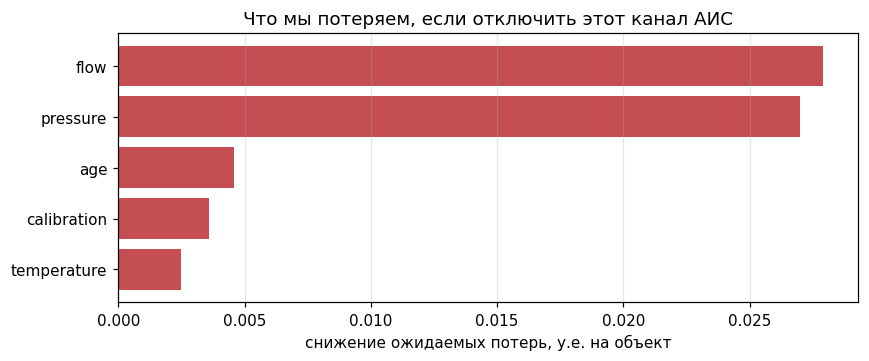

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.4))
order = voi.sort_values("вклад_сверх_остальных")
ax.barh(order["вход"], order["вклад_сверх_остальных"], color="#c44e52")
ax.set_xlabel("снижение ожидаемых потерь, у.е. на объект")
ax.set_title("Что мы потеряем, если отключить этот канал АИС")
ax.grid(axis="x", alpha=.3)
fig.tight_layout()
plt.show()

**Вывод.** Сеть воспроизводит качественную логику диплома, включая
explaining away, и после пересмотра структуры совпадает с Табл. 3.6 по
всем девяти числам (RMSE 0.047, максимум расхождения 0.075). Самые ценные
каналы — давление и расход; температура влияет слабо, но уже не нулевым
образом. Мёртвых входов в сети не осталось.

Важная оговорка, без которой цифру согласия читать нельзя: часть его
куплена подгонкой. `CPT_FAILURE` подобрана под шесть чисел Табл. 3.6
(гипотеза B), поэтому по узлу `failure_prob` сверка со сценариями стала
тавтологичной. Разбор — в ноутбуке 3.